# 4. Debt sustainability and policy options: how to put the debt on a declining path

**Questions.** Under current policies, where is the debt ratio heading? How sensitive is it to interest rates and growth? How large and how
long should a fiscal adjustment be for the debt to decline with high probability, as required by the 2024 EU economic governance framework?
Which combination of fiscal, tax, growth and debt-management measures achieves it at the lowest economic cost?

**Method.** Deterministic projections and a **stochastic debt sustainability analysis** (DSA) in the spirit of the European Commission and
the IMF: 100,000 Monte Carlo paths in C++, with shocks to growth, inflation and the long-term rate resampled from a VAR(1) estimated on
Italian data, an effective interest rate that reprices gradually with the maturity of the debt, automatic stabilisers and, optionally, a
fiscal reaction to debt.

**Assumptions.** The macroeconomic baseline in the next cell is illustrative and must be updated with the latest official forecasts
(Ministry of Economy, European Commission, Bank of Italy, Ufficio parlamentare di bilancio). The results are model-based illustrations
of trade-offs, not forecasts or policy endorsements.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "public_debt").is_dir())
try:
    import public_debt
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "public_debt"))
    import public_debt
from public_debt import accounting, data, dsa, fiscal, growth, synthetic
from public_debt.var import fit_var1

core = public_debt.require_cpp()

DATA_MODE = os.environ.get("PUBLIC_DEBT_DATA_MODE", "official")   # "official" (Eurostat, IMF) or "synthetic" (offline)
OFFICIAL = DATA_MODE == "official"
OUTPUT_DIR = ROOT / "outputs" / "sustainability"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from public_debt.figstyle import (MUTED, NEGATIVE, NOTEBOOK, SERIES, figure_headline, headline, label_ends,
                                  notebook_style, ordinal_colors)
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"public_debt {public_debt.__version__} | data mode: {DATA_MODE}")
if not OFFICIAL:
    print("WARNING: synthetic data. Tables and charts are placeholders, not statistics about Italy.")

# Baseline assumptions (edit with the latest official forecasts)
HORIZON = 10
REAL_GROWTH = 0.008          # potential growth of the Italian economy, about 0.5-1% in recent official estimates
INFLATION = 0.020            # GDP deflator, ECB target
REFINANCING_SHARE = 0.15     # about 1 / average residual maturity (close to 7 years) plus short-term bills
EPSILON = 0.5                # response of the primary balance to growth surprises (automatic stabilisers)
N_PATHS = 100_000
SEED = 20250101

public_debt 0.1.0 | data mode: official


## 4.1 Starting point

In [2]:
if OFFICIAL:
    it, yields = data.fiscal_dataset("IT"), data.bond_yields(("IT", "DE"))
else:
    it, yields = synthetic.fiscal_dataset(), synthetic.bond_yields()
d0 = float(it["debt"].iloc[-1]); i0 = float(it["effective_rate"].iloc[-1]); pb0 = float(it["primary_balance"].iloc[-1])
r0 = float(yields["IT"].dropna().iloc[-1]) / 100
first = int(it.index.max()) + 1
stab = float(accounting.stabilising_primary_balance(d0, r0, REAL_GROWTH, INFLATION))
print(f"Last year {first - 1}: debt {100 * d0:.1f}% of GDP, primary balance {100 * pb0:.2f}%, effective rate {100 * i0:.2f}%, "
      f"10-year yield {100 * r0:.2f}%")
print(f"Primary balance that stabilises the debt once the whole stock pays the market rate: {100 * stab:.2f}% of GDP")
base = dsa.Scenario.constant(first, HORIZON, REAL_GROWTH, INFLATION, r0, pb0)

Last year 2025: debt 137.1% of GDP, primary balance 0.80%, effective rate 2.97%, 10-year yield 3.59%
Primary balance that stabilises the debt once the whole stock pays the market rate: 1.04% of GDP


## 4.2 Deterministic scenarios

- **No policy change**: the primary balance stays at its last value.
- **Higher rates**: market rates 100 basis points higher (a spread shock).
- **Lower growth**: real growth 0.5 points lower.
- **Adverse**: both shocks together.
- **Seven-year plan**: the primary balance improves by 0.5% of GDP per year for seven years (the order of magnitude of the adjustment
  discussed under the new EU framework; see section 4.4 for the size actually needed).

year,2026,2030,2035
no policy change,136.60,135.60,135.60
higher rates (+100 bp),136.80,138.10,143.10
lower growth (-0.5 pp),137.30,139.10,142.80
adverse (both),137.50,141.70,150.70
seven-year plan (0.5 pp a year),136.10,128.10,110.60


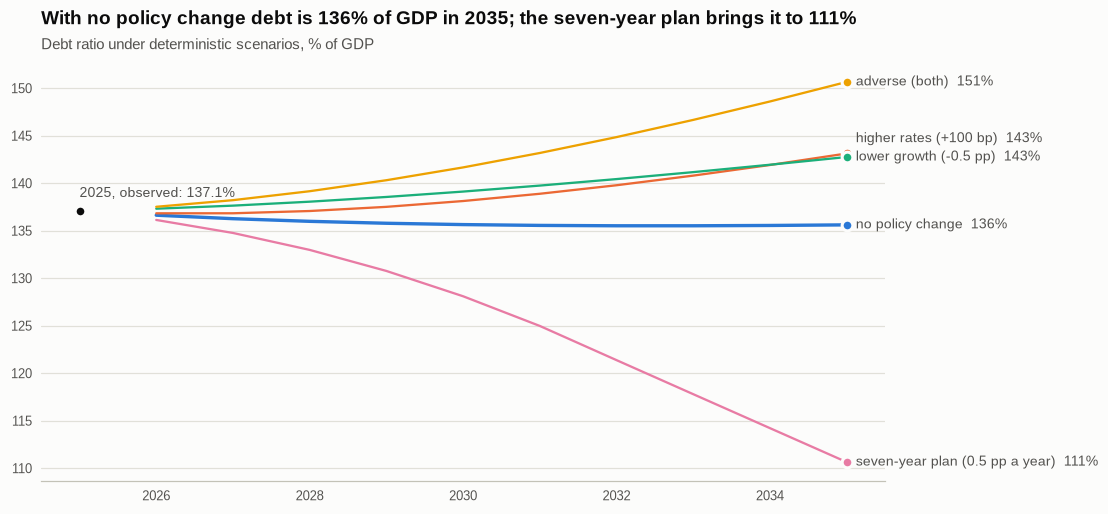

In [3]:
scenarios = {"no policy change": base, "higher rates (+100 bp)": base.shifted(market_rate=0.01),
             "lower growth (-0.5 pp)": base.shifted(growth=-0.005),
             "adverse (both)": base.shifted(market_rate=0.01, growth=-0.005),
             "seven-year plan (0.5 pp a year)": base.with_adjustment(0.005, 7)}
proj = {k: dsa.project(d0, i0, REFINANCING_SHARE, s) for k, s in scenarios.items()}
debt = pd.DataFrame({k: 100 * p["debt"] for k, p in proj.items()})
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = dict(zip(debt.columns, SERIES))
for k in debt:
    ax.plot(debt.index, debt[k], color=colors[k], lw=2.2 if k == "no policy change" else 1.5)
ax.plot([first - 1], [100 * d0], "o", color=NOTEBOOK["ink"], mec=NOTEBOOK["surface"], mew=2, ms=7)
ax.annotate(f"{first - 1}, observed: {100 * d0:.1f}%", (first - 1, 100 * d0), xytext=(0, 9), textcoords="offset points",
            ha="left", fontsize=9, color=NOTEBOOK["ink2"])
end = debt.iloc[-1]
headline(ax, f"With no policy change debt is {end['no policy change']:.0f}% of GDP in {debt.index[-1]}; the seven-year "
             f"plan brings it to {end['seven-year plan (0.5 pp a year)']:.0f}%",
         "Debt ratio under deterministic scenarios, % of GDP")
label_ends(ax, {k: debt[k] for k in debt}, colors, fmt=lambda v: f"{v:.0f}%")
fig.savefig(OUTPUT_DIR / "deterministic.png", dpi=150)
display(debt.iloc[[0, 4, 9]].T.round(1))

## 4.3 Stochastic debt sustainability analysis

A VAR(1) on real growth, inflation and the 10-year yield is estimated on the Italian data; its residuals (which include the 2008-2012 and
2020 shocks) are resampled year by year around the baseline. The fan chart shows percentiles of the debt ratio; the key indicator is the
probability that the debt ratio is higher at the end of the horizon than today.

VAR(1) on 1996-2025, stable: True; residual standard deviations (pp): {'real_growth': np.float64(3.01), 'inflation': np.float64(0.88), 'long_rate': np.float64(0.69)}


,real_growth,inflation,long_rate
real_growth,-0.08,0.42,-0.61
inflation,0.20,0.25,-0.06
long_rate,0.15,-0.10,0.77


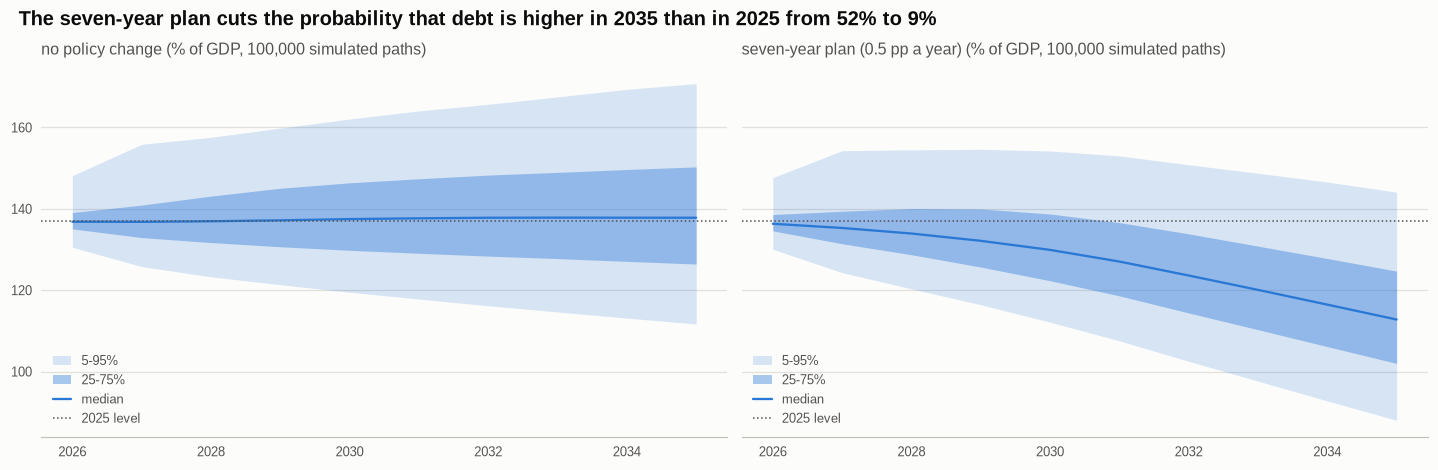

In [4]:
macro = pd.DataFrame({"real_growth": it["real_growth"], "inflation": it["inflation"],
                      "long_rate": yields["IT"].reindex(it.index) / 100}).dropna()
var = fit_var1(macro)
print(f"VAR(1) on {var.sample}, stable: {var.stable}; residual standard deviations (pp): "
      f"{dict(zip(var.names, np.round(100 * np.sqrt(np.diag(var.residual_cov)), 2)))}")
display(pd.DataFrame(var.A, index=var.names, columns=var.names).round(2))
u0 = np.zeros(3)   # start on the baseline; use var.last_deviation(macro) to start from today's deviations

fans = {k: dsa.stochastic(d0, i0, REFINANCING_SHARE, scenarios[k], var, u0, epsilon=EPSILON, n_paths=N_PATHS, seed=SEED)
        for k in ("no policy change", "seven-year plan (0.5 pp a year)")}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (k, fan) in zip(axes, fans.items()):
    p = 100 * fan["percentiles"]
    ax.fill_between(p.index, p["p5"], p["p95"], alpha=0.18, lw=0, color=SERIES[0], label="5-95%")
    ax.fill_between(p.index, p["p25"], p["p75"], alpha=0.4, lw=0, color=SERIES[0], label="25-75%")
    ax.plot(p.index, p["p50"], color=SERIES[0], label="median")
    ax.axhline(100 * d0, color=NOTEBOOK["ink2"], ls=":", lw=1.0, label=f"{first - 1} level")
    ax.set(title=f"{k} (% of GDP, {N_PATHS:,} simulated paths)")
    ax.legend(loc="lower left")
prob = {k: fan["prob_higher_than_start"].iloc[-1] for k, fan in fans.items()}
before, after = prob["no policy change"], prob["seven-year plan (0.5 pp a year)"]
figure_headline(fig, f"The seven-year plan {'cuts' if after < before else 'raises'} the probability that debt is higher in "
                     f"{p.index[-1]} than in {first - 1} from {before:.0%} to {after:.0%}")
fig.savefig(OUTPUT_DIR / "fan_charts.png", dpi=150)

## 4.4 How large an adjustment?

For plans of four or seven years and different annual improvements of the primary balance, the C++ engine computes the probability that the
debt ratio at the end of the horizon is higher than today. The 2024 EU framework asks that, after the adjustment, debt be on a plausibly
declining path, with a probability of at least 70% in the stochastic analysis (probability of a higher debt at most 30%).

In [5]:
steps = np.round(np.arange(0.0, 0.0101, 0.00125), 5)
grid = dsa.adjustment_grid(d0, i0, REFINANCING_SHARE, base, var, steps, [4, 7], None, base.years[-1], u0, EPSILON,
                           n_paths=20_000, seed=SEED)
display((100 * grid).round(1).rename(index=lambda s: f"{100 * s:.3f} pp").rename_axis("annual step"))
ok = grid[7] <= 0.30
needed = float(grid.index[ok.to_numpy().argmax()]) if ok.any() else None
print("Smallest seven-year annual step with P(debt higher) <= 30%: "
      + (f"{100 * needed:.2f}% of GDP a year" if needed is not None else "above the grid"))

plan = base.with_adjustment(needed if needed is not None else 0.01, 7)
plan_proj = dsa.project(d0, i0, REFINANCING_SHARE, plan)
display(dsa.eu_rules_check(plan_proj, d0, first + 6).to_frame("plan").T)

step = max(needed or 0.0, 0.005)   # illustrate the multiplier with at least 0.5 pp a year
no_mult = dsa.project(d0, i0, REFINANCING_SHARE, base.with_adjustment(step, 7))
mult_proj = dsa.project(d0, i0, REFINANCING_SHARE, dsa.with_fiscal_multiplier(base, step, 7, multiplier=0.8))
comp = pd.DataFrame({f"{100 * step:.2f} pp a year, no multiplier": 100 * no_mult["debt"],
                     f"{100 * step:.2f} pp a year, multiplier 0.8": 100 * mult_proj["debt"]})
display(comp.iloc[[0, 1, 2, 6, 9]].T.round(1))
print("With a multiplier the consolidation lowers growth in the short run, so the debt ratio falls more slowly at first; "
      "a larger multiplier (as in deep recessions, Blanchard and Leigh, 2013) can make the ratio rise temporarily.")

years of adjustment,4,7
annual step,,
0.000 pp,51.90,51.90
0.125 pp,41.90,37.80
0.250 pp,32.60,25.50
0.375 pp,24.60,16.40
0.500 pp,18.00,9.70
0.625 pp,12.70,5.30
0.750 pp,8.50,2.80
0.875 pp,5.60,1.20
1.000 pp,3.60,0.50


Smallest seven-year annual step with P(debt higher) <= 30%: 0.25% of GDP a year


,deficit <= 3% at end of adjustment,average debt decline >= 1 pp per year,deficit <= 1.5% (resilience),debt declining after adjustment,average annual debt change during adjustment (pp)
plan,True,True,False,True,-1.24


year,2026,2027,2028,2032,2035
"0.50 pp a year, no multiplier",136.10,134.80,133.00,121.40,110.60
"0.50 pp a year, multiplier 0.8",136.90,136.10,134.80,124.90,113.70


With a multiplier the consolidation lowers growth in the short run, so the debt ratio falls more slowly at first; a larger multiplier (as in deep recessions, Blanchard and Leigh, 2013) can make the ratio rise temporarily.


## 4.5 Policy levers compared

Each lever is expressed as a change to the baseline; the table reports the debt ratio after ten years and the probability that it is higher
than today. Sizes are illustrative and chosen to be plausible for Italy:

| Lever | Modelled as |
| --- | --- |
| Spending review | permanent improvement of the primary balance of 0.5% of GDP from year 1 |
| Tax compliance | revenues rising gradually to +0.7% of GDP by year 5 (a reduction of the tax gap by roughly a sixth) |
| Growth-enhancing reforms | real growth +0.5 points from year 3 (labour participation, justice, public administration, innovation) |
| Asset sales | one-off reduction of debt by 1% of GDP in year 1 (stock-flow adjustment) |
| Longer maturity | refinancing share 0.10 instead of 0.15: cost of a +100 bp rate shock with each maturity |
| Package | spending review + tax compliance + reforms + asset sales |

In [6]:
ramp = np.minimum(np.arange(1, HORIZON + 1) / 5, 1.0) * 0.007
reform = np.where(np.arange(1, HORIZON + 1) >= 3, 0.005, 0.0)
sale = np.r_[-0.01, np.zeros(HORIZON - 1)]
levers = {
    "no policy change": (base, REFINANCING_SHARE),
    "spending review 0.5% of GDP": (base.shifted(primary_balance=0.005), REFINANCING_SHARE),
    "tax compliance (+0.7% by year 5)": (base.shifted(primary_balance=ramp), REFINANCING_SHARE),
    "growth reforms (+0.5 pp)": (base.shifted(growth=reform), REFINANCING_SHARE),
    "asset sales (1% of GDP)": (base.shifted(sfa=sale), REFINANCING_SHARE),
    "package": (base.shifted(primary_balance=0.005 + ramp, growth=reform, sfa=sale), REFINANCING_SHARE),
}
rows = {}
for name, (sc, share) in levers.items():
    det = dsa.project(d0, i0, share, sc)["debt"].iloc[-1]
    fan = dsa.stochastic(d0, i0, share, sc, var, u0, epsilon=EPSILON, n_paths=20_000, seed=SEED)
    rows[name] = {f"debt {sc.years[-1]} (%)": 100 * det, "change vs no policy change (pp)": np.nan,
                  "P(debt higher than today)": fan["prob_higher_than_start"].iloc[-1]}
levers_table = pd.DataFrame(rows).T
col = levers_table.columns[0]
levers_table["change vs no policy change (pp)"] = levers_table[col] - levers_table.loc["no policy change", col]
display(levers_table.round(2))
levers_table.to_csv(OUTPUT_DIR / "policy_levers.csv")

shock_cost = {}
for label, share in (("current maturity (share 0.15)", REFINANCING_SHARE), ("longer maturity (share 0.10)", 0.10)):
    shocked = dsa.project(d0, i0, share, base.shifted(market_rate=0.01))["debt"]
    unshocked = dsa.project(d0, i0, share, base)["debt"]
    shock_cost[label] = 100 * (shocked - unshocked)
display(pd.DataFrame(shock_cost).iloc[[0, 2, 4, 9]].T.round(2).rename(columns=lambda y: f"extra debt {y} (pp)"))
print("A longer maturity slows the pass-through of a rate shock to the interest bill and to the debt ratio.")

,debt 2035 (%),change vs no policy change (pp),P(debt higher than today)
no policy change,135.61,0.00,0.52
spending review 0.5% of GDP,130.48,-5.13,0.40
tax compliance (+0.7% by year 5),129.89,-5.72,0.39
growth reforms (+0.5 pp),130.21,-5.40,0.39
asset sales (1% of GDP),134.57,-1.05,0.49
package,118.57,-17.04,0.18


year,extra debt 2026 (pp),extra debt 2028 (pp),extra debt 2030 (pp),extra debt 2035 (pp)
current maturity (share 0.15),0.20,1.09,2.48,7.51
longer maturity (share 0.10),0.13,0.75,1.76,5.63


A longer maturity slows the pass-through of a rate shock to the interest bill and to the debt ratio.


## 4.6 Recommendations

The analysis supports a strategy built on four pillars. It is evidence-based and deliberately non-partisan: the choice among instruments
involves distributional and political judgements that the model does not make.

1. **A credible, gradual and sustained primary surplus.** The primary balance must exceed the debt-stabilising level (section 4.1) by a
   margin that absorbs shocks; the grid in section 4.4 quantifies the annual step. Anchor it in the EU medium-term fiscal-structural plan
   and its net expenditure path, save windfalls (the lesson of the early euro years), and use escape clauses in deep recessions rather than
   pro-cyclical cuts (the lesson of 2011-2013).
2. **Better composition rather than across-the-board cuts.** Italy spends relatively more on pensions and interest and less on education,
   family policies and public investment (notebook 2). Protect the notional defined-contribution pension system from new early-retirement
   windows, run systematic spending reviews and evaluate tax expenditures and tax credits ex ante (the lesson of the building bonuses).
3. **Broader tax base, lower tax wedge.** Reduce evasion through electronic invoicing, traceable payments and data matching; use the proceeds
   to lower the tax wedge on labour, which supports employment and growth.
4. **Growth as the main lever.** Raising female and youth employment, speeding up civil justice and administration, supporting innovation
   and firm growth, and executing investment under the recovery plan act on the denominator and on the tax base (notebook 3). They matter
   more than any one-off measure.

**Debt management** complements these pillars: keeping a long average maturity limits the pass-through of rate shocks, and a diversified
investor base (including retail bonds) lowers refinancing risk. Asset sales help only at the margin and only if they do not reduce future
revenues by more than the interest saved.

### Limitations

- Illustrative baseline; no feedback from debt to interest rates (risk premium) beyond the resampled shocks; primary balance shocks only
  through growth; the VAR is estimated on a short sample (from 1995).
- The EU rules check is a simplified reading of the 2024 framework; the official assessment uses the Commission's DSA methodology.

### References

- Blanchard, O. (2019). Public debt and low interest rates. *American Economic Review*, 109(4), 1197-1229.
- Blanchard, O. and Leigh, D. (2013). Growth forecast errors and fiscal multipliers. *American Economic Review*, 103(3), 117-120.
- European Commission. *Debt Sustainability Monitor 2023* and later editions; Regulation (EU) 2024/1263 on the preventive arm of the Stability and Growth Pact.
- IMF (2021). Review of the Debt Sustainability Framework for Market Access Countries. Policy Paper 2021/003.
- Ufficio parlamentare di bilancio. *Rapporto sulla politica di bilancio*; Banca d'Italia. *Relazione annuale*.